example: https://empresas.blogthinkbig.com/como-interpretar-la-matriz-de-confusion-ejemplo-practico/


https://fairmodel.econ.yale.edu/rayfair/pdf/2011b.htm

rate_marriage: How rate marriage(como califica su matrimonio)

1 = very poor (muy pobre)

2 = poor (pobre)

3 = fair (justa)

4 = good (buena)

5 = very good (muy buena)

age: la edad

yrs_married: años de casada

children: No Children

religious: how religious (cuán religioso), 1:not (no), 2:midly(medianamente) , 3:faily(deficientemente) , 4:strongly(fuertemente)

educ: nivel de educación,
9 = grade school
12= high school
14= some college
16= college graduate
17=some graduate school
20=advance degree

ocupation: Ocupación
1= student
2= farming, agriculture, some-skilled, unskilled worker
3= white-colloar
4= teacher-counseler social worker, nursing, artirst, writers, technician, skiller worker
5= managerial





In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
url =  'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/affairs.csv'

df = pd.read_csv(url, delimiter=',')
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affair
0,3,32.0,9.0,3.0,3,17,2,5,1
1,3,27.0,13.0,3.0,1,14,3,4,1
2,4,22.0,2.5,0.0,1,16,3,5,1
3,4,37.0,16.5,4.0,3,16,5,5,1
4,5,27.0,9.0,1.0,1,14,3,4,1


In [3]:
df.shape

(6366, 9)

In [4]:
df['affair'].value_counts()

,count
affair,
0,4313
1,2053


In [5]:
X = df.drop("affair", axis=1)
y = df.affair
X.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb
0,3,32.0,9.0,3.0,3,17,2,5
1,3,27.0,13.0,3.0,1,14,3,4
2,4,22.0,2.5,0.0,1,16,3,5
3,4,37.0,16.5,4.0,3,16,5,5
4,5,27.0,9.0,1.0,1,14,3,4


In [6]:
from sklearn.feature_selection import SelectKBest

best=SelectKBest(k=4)
X_new = best.fit_transform(X, y)
X_new.shape
selected = best.get_support(indices=True)
print(X.columns[selected])

Index(['rate_marriage', 'age', 'yrs_married', 'children'], dtype='object')


In [7]:
X_new

array([[ 3. , 32. ,  9. ,  3. ],
       [ 3. , 27. , 13. ,  3. ],
       [ 4. , 22. ,  2.5,  0. ],
       ...,
       [ 5. , 22. ,  2.5,  0. ],
       [ 5. , 32. ,  6. ,  1. ],
       [ 4. , 22. ,  2.5,  0. ]])

<Axes: title={'center': 'Pearson Correlation of Features'}>

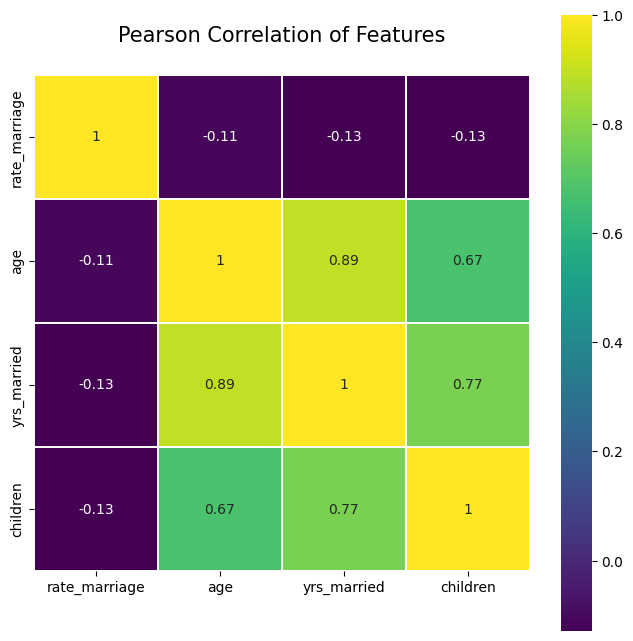

In [8]:
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sb

used_features =X.columns[selected]

colormap = plt.cm.viridis
plt.figure(figsize=(8,8))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sb.heatmap(df[used_features].astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [9]:
X=df[used_features]

In [10]:
X.head()

,rate_marriage,age,yrs_married,children
0,3,32.0,9.0,3.0
1,3,27.0,13.0,3.0
2,4,22.0,2.5,0.0
3,4,37.0,16.5,4.0
4,5,27.0,9.0,1.0


In [11]:
from sklearn.preprocessing import StandardScaler
#Seperar el dataframe en datos de train y datos de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# Escalar los datos de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_test.shape,X_train.shape

((1274, 4), (5092, 4))

In [13]:
modelo = linear_model.LogisticRegression(C=0.03,solver='liblinear',max_iter=100, random_state=None)

In [14]:
#Entrenamiento del Modelo
modelo.fit(X_train_scaled,y_train)

LogisticRegression(C=0.03, solver='liblinear')

In [15]:
from sklearn import model_selection
seed = 7
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=10, random_state=seed,shuffle=True)
cv_results = model_selection.cross_val_score(modelo, X_train, y_train, cv=kfold, scoring='accuracy')
msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
print(msg)

Logistic Regression: 0.710324 (0.016987)


In [16]:
# Predecimos sobre nuestro set de traint
y_pred = modelo.predict(X_test_scaled)
print(y_pred)

[0 0 1 ... 0 0 0]


Generamos las metricas de evaluación

"Accuracy" es la precisión { Si recordamos, la exactitud (o «accuracy«) representa el porcentaje de predicciones correctas frente al total.}

"Precision" es la exactitud {La precisión, (o“precision”) se refiere a lo cerca que está el resultado de una predicción del valor verdadero. }

"Recall" es la sensibilidad {La sensibilidad (o recall) representa la tasa de verdaderos positivos (True Positive Rate) ó TP.}

In [18]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("F1: ", f1_score(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

Accuracy:  0.7025117739403454
Recall:  0.31630170316301703
Precision:  0.5701754385964912
F1:  0.40688575899843504
R2:  -0.3613068202642846


In [20]:
#generamos la matriz de confusión

cnf_matrix=confusion_matrix(y_test, y_pred)
cnf_matrix

array([[765,  98],
       [281, 130]])

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80       863
           1       0.57      0.32      0.41       411

    accuracy                           0.70      1274
   macro avg       0.65      0.60      0.60      1274
weighted avg       0.68      0.70      0.67      1274



Text(0.5, 427.9555555555555, 'Predicted Label')

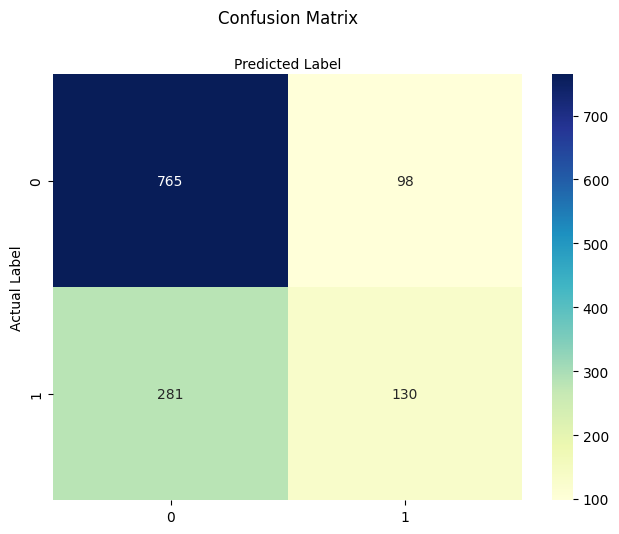

In [23]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix', y=1.1)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

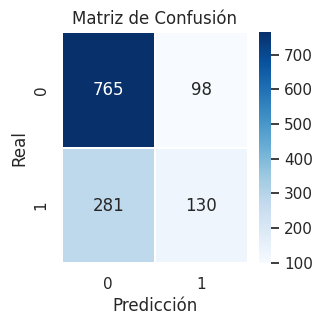

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

sns.set()

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
f, (ax1) = plt.subplots(figsize=(3,3),nrows=1)

# crear mapa de calor dibujar mapa de calor: cmap="Reds"
sns.heatmap(pd.DataFrame(cm),linewidths = 0.05, annot=True, cmap="Blues",fmt='g')
ax1.set_title('Matriz de Confusión') #título
ax1.set_xlabel('Predicción') #eje x
ax1.set_ylabel('Real') #eje y
f.savefig('RF-1.jpg')

##Usando Arboles de Decisión

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
#Crear el modelo de Arbol para Clasificación
modelotree = DecisionTreeClassifier(max_depth = 3)

In [27]:
#Entrenamiento del Modelo
modelotree.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=3)

In [28]:
# Predecimos sobre nuestro set de traint
pred_test = modelotree.predict(X_test_scaled)

In [29]:
print('Accuracy sobre conjunto de Test:', accuracy_score(pred_test,y_test))

Accuracy sobre conjunto de Test: 0.7017268445839875


In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

Profundidad del árbol: 3
Número de nodos terminales: 8


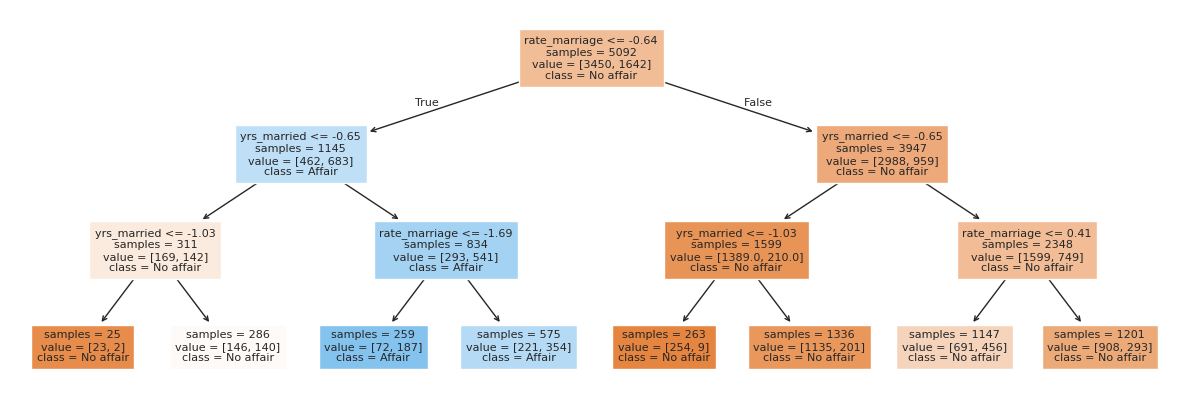

In [32]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

print(f"Profundidad del árbol: {modelotree.get_depth()}")
print(f"Número de nodos terminales: {modelotree.get_n_leaves()}")

plot = plot_tree(
    decision_tree = modelotree,
    feature_names = df.drop(columns = "affair").columns,
    class_names = ['No affair', 'Affair'],  # ← Aquí va una lista, no un string
    filled = True,
    impurity = False,
    fontsize = 8,
    precision = 2,
    ax = ax
)

In [33]:
#generamos la matriz de confusión

cnf_matrix=confusion_matrix(y_test, pred_test)
cnf_matrix

array([[769,  94],
       [286, 125]])

In [34]:
print("Accuracy: ",accuracy_score(y_test,pred_test))
print("Recall: ",recall_score(y_test,pred_test))
print("Precision: ",precision_score(y_test,pred_test))
print("F1: ",f1_score(y_test,pred_test))
print("R2: ",r2_score(y_test,pred_test))

Accuracy:  0.7017268445839875
Recall:  0.30413625304136255
Precision:  0.5707762557077626
F1:  0.3968253968253968
R2:  -0.3648986588401799


#Random Forest

In [35]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(max_depth=3,criterion='entropy',min_samples_split=5, min_samples_leaf=2,n_estimators=20)

modelRF.fit(X_train_scaled,y_train)

y_pred = modelRF.predict(X_test_scaled)

randomForest_score = accuracy_score(y_test, y_pred)

print("Random Forest Score :{}".format(randomForest_score))

Random Forest Score :0.7025117739403454


In [36]:
#generamos la matriz de confusión

cnf_matrix=confusion_matrix(y_test, y_pred)
cnf_matrix

array([[768,  95],
       [284, 127]])

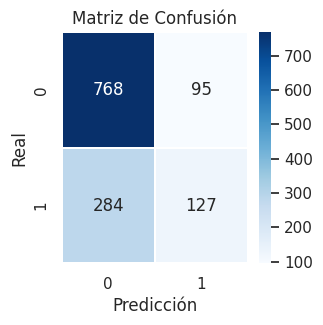

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

sns.set()

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
f, (ax1) = plt.subplots(figsize=(3,3),nrows=1)

# crear mapa de calor dibujar mapa de calor: cmap="Reds"
sns.heatmap(pd.DataFrame(cm),linewidths = 0.05, annot=True, cmap="Blues",fmt='g')
ax1.set_title('Matriz de Confusión') #título
ax1.set_xlabel('Predicción') #eje x
ax1.set_ylabel('Real') #eje y
f.savefig('RF-1.jpg')

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80       863
           1       0.57      0.31      0.40       411

    accuracy                           0.70      1274
   macro avg       0.65      0.60      0.60      1274
weighted avg       0.68      0.70      0.67      1274



In [39]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Recall: ",recall_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))
print("F1: ",f1_score(y_test,y_pred))
print("R2: ",r2_score(y_test,y_pred))

Accuracy:  0.7025117739403454
Recall:  0.30900243309002434
Precision:  0.5720720720720721
F1:  0.40126382306477093
R2:  -0.3613068202642846


#SVM

In [40]:
#SVM
from sklearn import svm

modelSVM = svm.SVC(kernel='rbf')

modelSVM.fit(X_train_scaled, y_train)

y_pred = modelSVM.predict(X_test_scaled)

svm_score=accuracy_score(y_test, y_pred)

print("SVM's Accuracy:{0}".format(accuracy_score(y_test, y_pred)))

SVM's Accuracy:0.7040816326530612


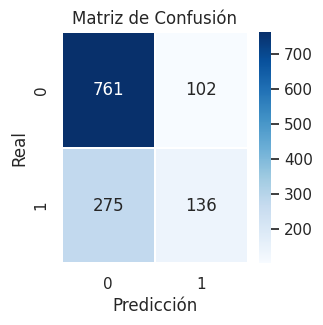

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

sns.set()

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
f, (ax1) = plt.subplots(figsize=(3,3),nrows=1)

# crear mapa de calor dibujar mapa de calor: cmap="Reds"
sns.heatmap(pd.DataFrame(cm),linewidths = 0.05, annot=True, cmap="Blues",fmt='g')
ax1.set_title('Matriz de Confusión') #título
ax1.set_xlabel('Predicción') #eje x
ax1.set_ylabel('Real') #eje y
f.savefig('SVM-1.jpg')

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.88      0.80       863
           1       0.57      0.33      0.42       411

    accuracy                           0.70      1274
   macro avg       0.65      0.61      0.61      1274
weighted avg       0.68      0.70      0.68      1274



In [43]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Recall: ",recall_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))
print("F1: ",f1_score(y_test,y_pred))
print("R2: ",r2_score(y_test,y_pred))

Accuracy:  0.7040816326530612
Recall:  0.3309002433090024
Precision:  0.5714285714285714
F1:  0.41910631741140214
R2:  -0.35412314311249427


#Modelos Basados en Boosting

In [44]:
# Primero, importar las librerías necesarias para los modelos de boosting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn import linear_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.metrics import classification_report, confusion_matrix

# Modelos de Boosting
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [45]:
# Cargar los datos
url = 'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/affairs.csv'
df = pd.read_csv(url, delimiter=',')
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affair
0,3,32.0,9.0,3.0,3,17,2,5,1
1,3,27.0,13.0,3.0,1,14,3,4,1
2,4,22.0,2.5,0.0,1,16,3,5,1
3,4,37.0,16.5,4.0,3,16,5,5,1
4,5,27.0,9.0,1.0,1,14,3,4,1


In [46]:
# Ver la estructura de los datos
print(f"Forma del dataset: {df.shape}")
print("\nDistribución de la variable objetivo:")
print(df['affair'].value_counts())
print(f"\nProporción de casos positivos (affair=1): {df['affair'].mean():.2%}")

Forma del dataset: (6366, 9)

Distribución de la variable objetivo:
affair
0    4313
1    2053
Name: count, dtype: int64

Proporción de casos positivos (affair=1): 32.25%


In [47]:
# Separar características y variable objetivo
X = df.drop("affair", axis=1)
y = df.affair

# Selección de características usando SelectKBest
best = SelectKBest(k=4)
X_new = best.fit_transform(X, y)
selected = best.get_support(indices=True)
print("Características seleccionadas:")
print(X.columns[selected])

# Usar solo las características seleccionadas
used_features = X.columns[selected]
X = df[used_features]

Características seleccionadas:
Index(['rate_marriage', 'age', 'yrs_married', 'children'], dtype='object')


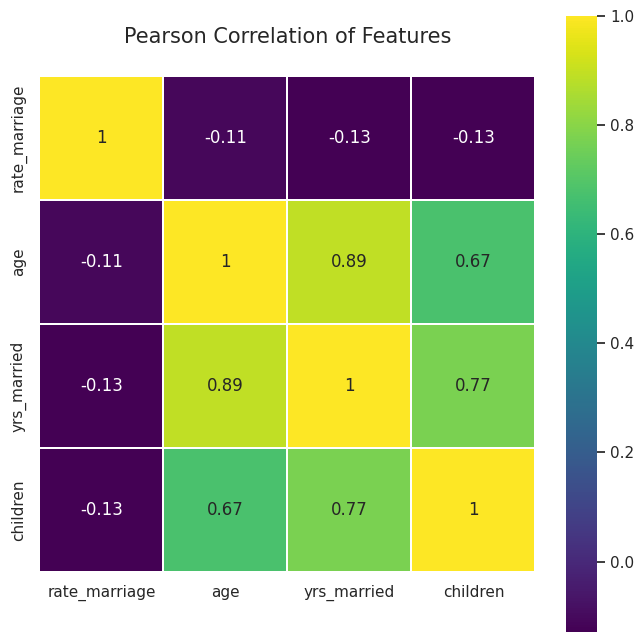

In [48]:
# Análisis de correlación de características seleccionadas
plt.figure(figsize=(8, 8))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(df[used_features].astype(float).corr(), linewidths=0.1, vmax=1.0,
            square=True, cmap=plt.cm.viridis, linecolor='white', annot=True)
plt.show()

In [49]:
# Preparar datos para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (5092, 4)
Tamaño del conjunto de prueba: (1274, 4)


MODELO BASE: Regresión Logística
Validación cruzada - Accuracy: 0.7231 (±0.0111)

Métricas en conjunto de prueba:
Accuracy: 0.7025
Precision: 0.5702
Recall: 0.3163
F1-Score: 0.4069

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.73      0.89      0.80       863
           1       0.57      0.32      0.41       411

    accuracy                           0.70      1274
   macro avg       0.65      0.60      0.60      1274
weighted avg       0.68      0.70      0.67      1274



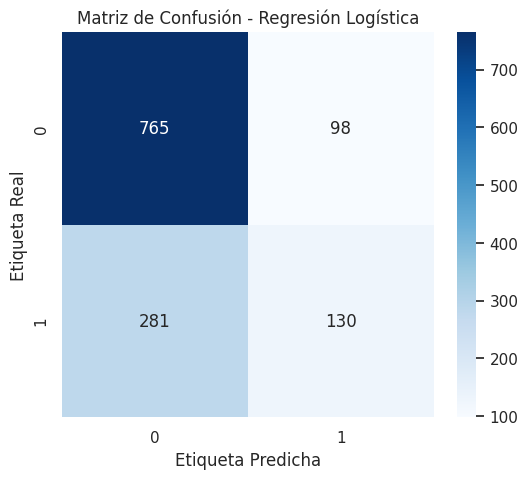

In [50]:
# 1. MODELO BASE: Regresión Logística (para comparación)
print("=" * 60)
print("MODELO BASE: Regresión Logística")
print("=" * 60)

log_reg = linear_model.LogisticRegression(C=0.03, solver='liblinear', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Evaluación con validación cruzada
kfold = KFold(n_splits=10, random_state=42, shuffle=True)
cv_results = cross_val_score(log_reg, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f"Validación cruzada - Accuracy: {cv_results.mean():.4f} (±{cv_results.std():.4f})")

# Predicciones y métricas en test
y_pred_log = log_reg.predict(X_test_scaled)
print(f"\nMétricas en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log):.4f}")

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

In [52]:
# 2. MODELO DE BOOSTING: AdaBoost
print("\n" + "=" * 60)
print("MODELO: AdaBoost Classifier")
print("=" * 60)

# Crear y entrenar el modelo AdaBoost
ada_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_boost.fit(X_train_scaled, y_train)

# Evaluación con validación cruzada
cv_results_ada = cross_val_score(ada_boost, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f"Validación cruzada - Accuracy: {cv_results_ada.mean():.4f} (±{cv_results_ada.std():.4f})")

# Predicciones y métricas en test
y_pred_ada = ada_boost.predict(X_test_scaled)
print(f"\nMétricas en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ada):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ada):.4f}")

# Importancia de características
feature_importance_ada = pd.DataFrame({
    'feature': used_features,
    'importance': ada_boost.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de características (AdaBoost):")
print(feature_importance_ada)


MODELO: AdaBoost Classifier
Validación cruzada - Accuracy: 0.7262 (±0.0170)

Métricas en conjunto de prueba:
Accuracy: 0.7017
Precision: 0.5708
Recall: 0.3041
F1-Score: 0.3968

Importancia de características (AdaBoost):
         feature  importance
2    yrs_married    0.685113
0  rate_marriage    0.314887
1            age    0.000000
3       children    0.000000


In [53]:
# 3. MODELO DE BOOSTING: Gradient Boosting
print("\n" + "=" * 60)
print("MODELO: Gradient Boosting Classifier")
print("=" * 60)

# Crear y entrenar el modelo Gradient Boosting
grad_boost = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

grad_boost.fit(X_train_scaled, y_train)

# Evaluación con validación cruzada
cv_results_grad = cross_val_score(grad_boost, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f"Validación cruzada - Accuracy: {cv_results_grad.mean():.4f} (±{cv_results_grad.std():.4f})")

# Predicciones y métricas en test
y_pred_grad = grad_boost.predict(X_test_scaled)
print(f"\nMétricas en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_grad):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_grad):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_grad):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_grad):.4f}")

# Importancia de características
feature_importance_grad = pd.DataFrame({
    'feature': used_features,
    'importance': grad_boost.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de características (Gradient Boosting):")
print(feature_importance_grad)


MODELO: Gradient Boosting Classifier
Validación cruzada - Accuracy: 0.7227 (±0.0155)

Métricas en conjunto de prueba:
Accuracy: 0.7041
Precision: 0.5659
Recall: 0.3552
F1-Score: 0.4365

Importancia de características (Gradient Boosting):
         feature  importance
0  rate_marriage    0.591494
2    yrs_married    0.278737
1            age    0.077610
3       children    0.052158


In [55]:
# 4. MODELO DE BOOSTING: XGBoost
print("\n" + "=" * 60)
print("MODELO: XGBoost Classifier")
print("=" * 60)

# Crear y entrenar el modelo XGBoost
xgb_boost = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0  # ← Silencia mensajes de entrenamiento
)

xgb_boost.fit(X_train_scaled, y_train)

# Evaluación con validación cruzada
cv_results_xgb = cross_val_score(xgb_boost, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f"Validación cruzada - Accuracy: {cv_results_xgb.mean():.4f} (±{cv_results_xgb.std():.4f})")

# Predicciones y métricas en test
y_pred_xgb = xgb_boost.predict(X_test_scaled)
print(f"\nMétricas en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

# Importancia de características
feature_importance_xgb = pd.DataFrame({
    'feature': used_features,
    'importance': xgb_boost.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de características (XGBoost):")
print(feature_importance_xgb)


MODELO: XGBoost Classifier
Validación cruzada - Accuracy: 0.7231 (±0.0135)

Métricas en conjunto de prueba:
Accuracy: 0.7064
Precision: 0.5743
Recall: 0.3479
F1-Score: 0.4333

Importancia de características (XGBoost):
         feature  importance
0  rate_marriage    0.590106
2    yrs_married    0.280863
1            age    0.066476
3       children    0.062555


COMPARACIÓN DE TODOS LOS MODELOS

Comparación de métricas en conjunto de prueba:
             Modelo  Accuracy  Precision   Recall  F1-Score
Regresión Logística  0.702512   0.570175 0.316302  0.406886
           AdaBoost  0.701727   0.570776 0.304136  0.396825
  Gradient Boosting  0.704082   0.565891 0.355231  0.436472
            XGBoost  0.706436   0.574297 0.347932  0.433333


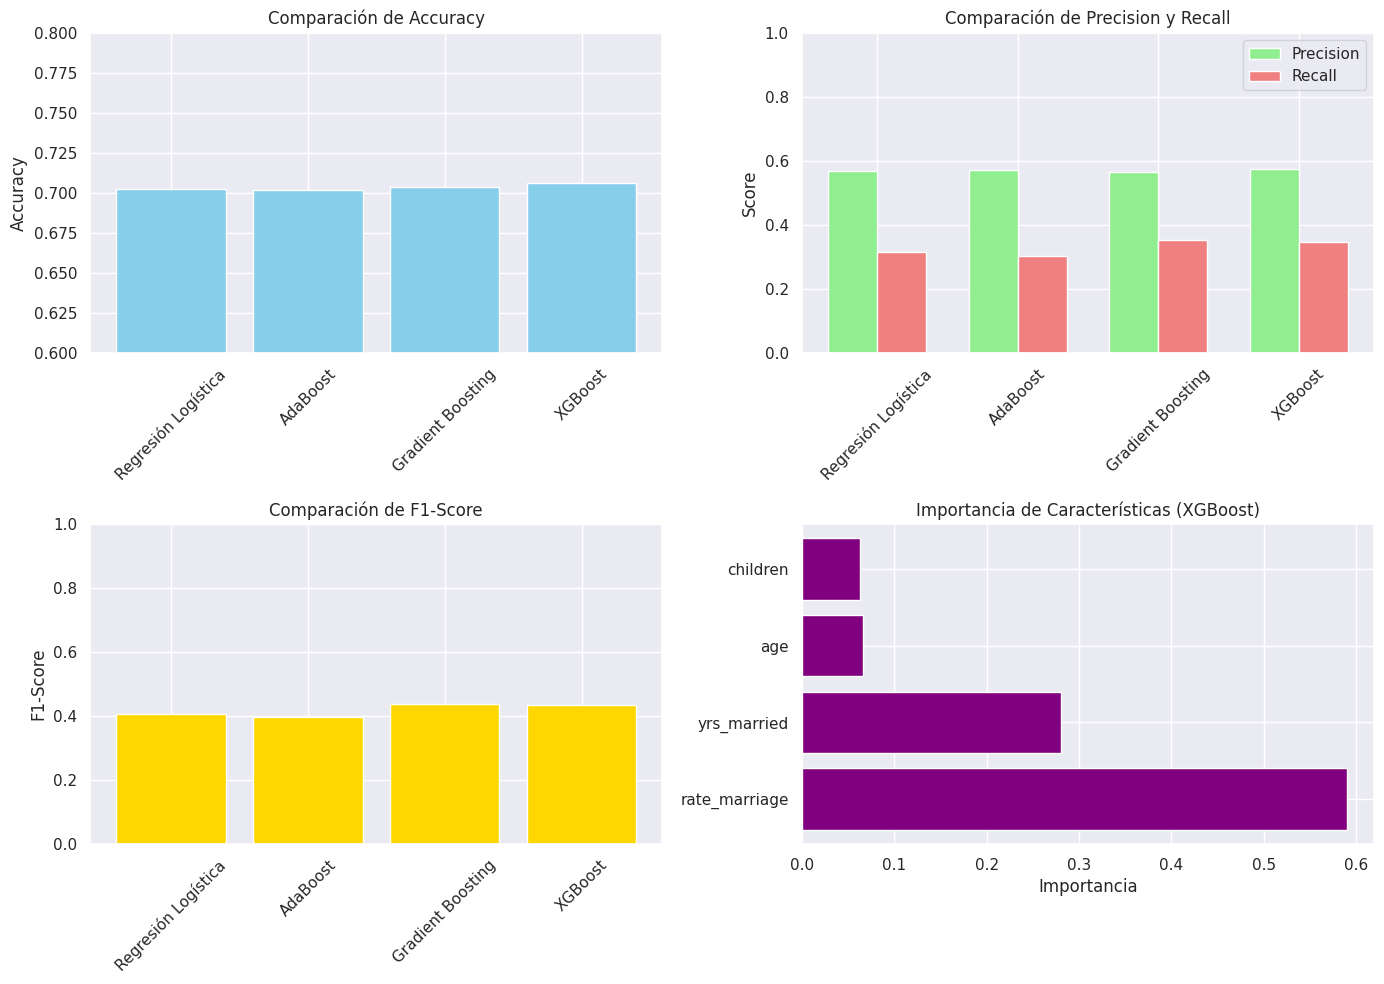

In [56]:
# Comparación de todos los modelos
print("=" * 60)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("=" * 60)

# Crear DataFrame con resultados
results_comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_grad),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_grad),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_grad),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_grad),
        f1_score(y_test, y_pred_xgb)
    ]
})

print("\nComparación de métricas en conjunto de prueba:")
print(results_comparison.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Accuracy comparativo
axes[0, 0].bar(results_comparison['Modelo'], results_comparison['Accuracy'], color='skyblue')
axes[0, 0].set_title('Comparación de Accuracy')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0.6, 0.8)
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Precision y Recall
x = np.arange(len(results_comparison['Modelo']))
width = 0.35
axes[0, 1].bar(x - width/2, results_comparison['Precision'], width, label='Precision', color='lightgreen')
axes[0, 1].bar(x + width/2, results_comparison['Recall'], width, label='Recall', color='lightcoral')
axes[0, 1].set_title('Comparación de Precision y Recall')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(results_comparison['Modelo'], rotation=45)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1)

# Gráfico 3: F1-Score
axes[1, 0].bar(results_comparison['Modelo'], results_comparison['F1-Score'], color='gold')
axes[1, 0].set_title('Comparación de F1-Score')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Importancia de características (XGBoost)
axes[1, 1].barh(feature_importance_xgb['feature'], feature_importance_xgb['importance'], color='purple')
axes[1, 1].set_title('Importancia de Características (XGBoost)')
axes[1, 1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

In [59]:
# Optimización de hiperparámetros para el mejor modelo
print("=" * 60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS PARA XGBOOST")
print("=" * 60)

# Definir parámetros para búsqueda en grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Crear modelo base para GridSearch
xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# GridSearch con validación cruzada
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Realizando búsqueda de hiperparámetros...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor score en validación cruzada: {grid_search.best_score_:.4f}")

# Evaluar el mejor modelo en test
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)

print(f"\nMétricas del modelo optimizado en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")

OPTIMIZACIÓN DE HIPERPARÁMETROS PARA XGBOOST
Realizando búsqueda de hiperparámetros...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Mejores parámetros encontrados:
  colsample_bytree: 0.7
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 150
  subsample: 0.7

Mejor score en validación cruzada: 0.7272

Métricas del modelo optimizado en conjunto de prueba:
Accuracy: 0.7049
Precision: 0.5692
Recall: 0.3504
F1-Score: 0.4337


ANÁLISIS DETALLADO DEL MEJOR MODELO


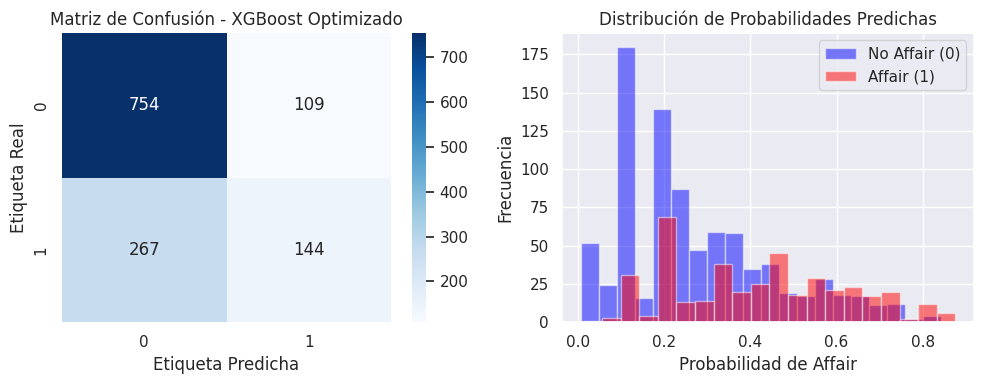


Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       863
           1       0.57      0.35      0.43       411

    accuracy                           0.70      1274
   macro avg       0.65      0.61      0.62      1274
weighted avg       0.68      0.70      0.68      1274


Número total de errores: 376
Tasa de error: 29.51%


In [58]:
# Análisis de predicciones del mejor modelo
print("=" * 60)
print("ANÁLISIS DETALLADO DEL MEJOR MODELO")
print("=" * 60)

# Matriz de confusión del modelo optimizado
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - XGBoost Optimizado')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')

# Distribución de probabilidades
y_prob_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

plt.subplot(1, 2, 2)
plt.hist(y_prob_best[y_test == 0], bins=20, alpha=0.5, label='No Affair (0)', color='blue')
plt.hist(y_prob_best[y_test == 1], bins=20, alpha=0.5, label='Affair (1)', color='red')
plt.title('Distribución de Probabilidades Predichas')
plt.xlabel('Probabilidad de Affair')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

# Reporte de clasificación detallado
print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred_best))

# Análisis de errores comunes
errors_idx = np.where(y_pred_best != y_test)[0]
print(f"\nNúmero total de errores: {len(errors_idx)}")
print(f"Tasa de error: {len(errors_idx)/len(y_test):.2%}")

COMPARACIÓN DE IMPORTANCIA DE CARACTERÍSTICAS


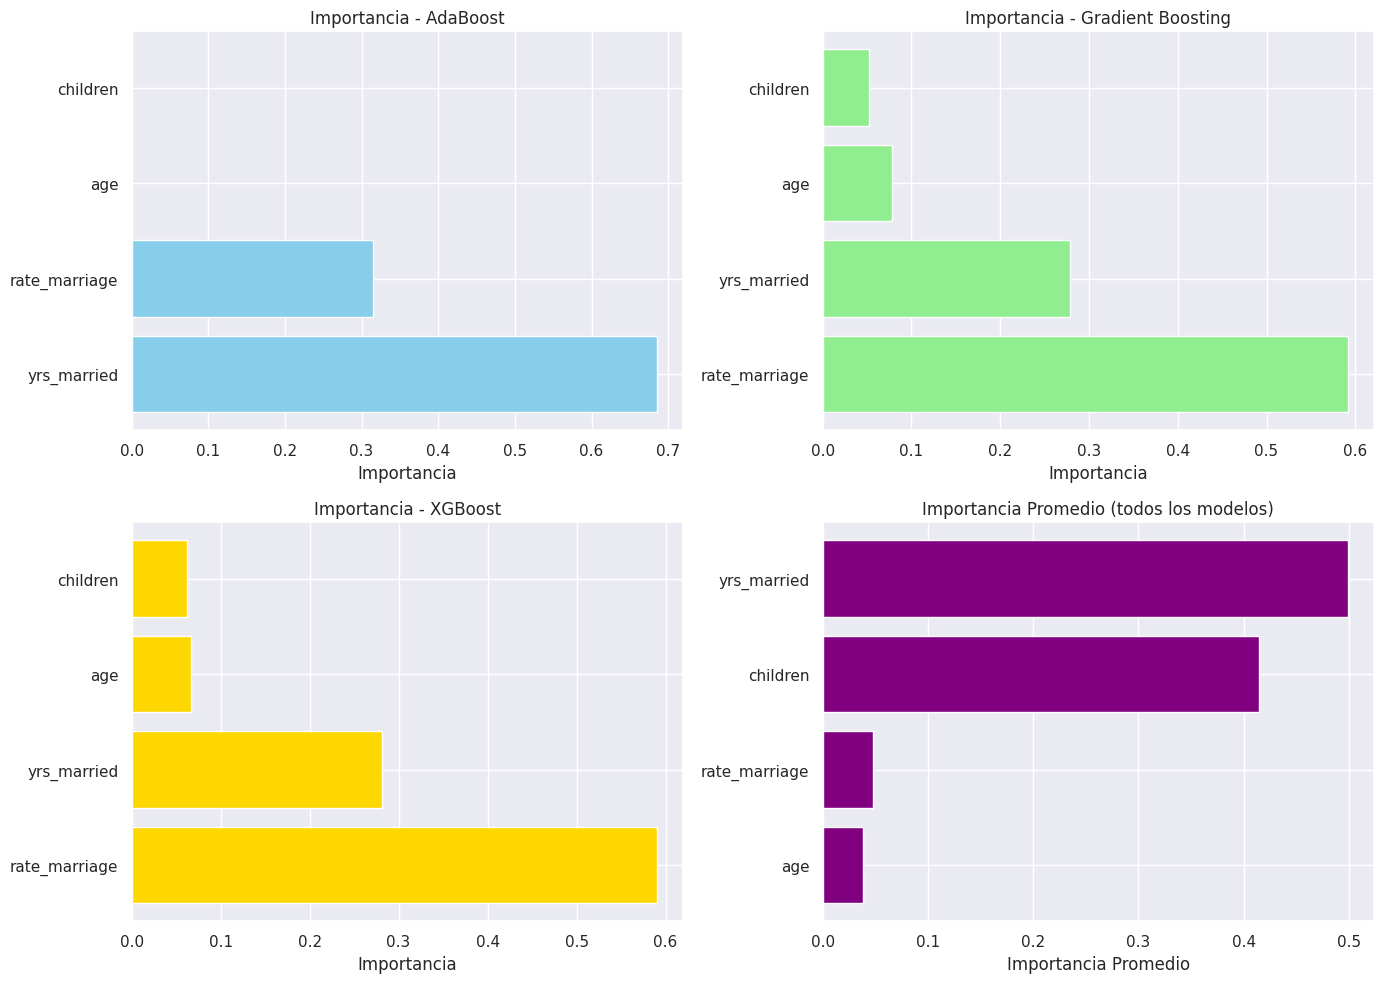


Importancia promedio de características:
      feature  avg_importance
  yrs_married        0.498829
     children        0.414904
rate_marriage        0.048029
          age        0.038238


In [60]:
# Visualización de la importancia de características de todos los modelos
print("=" * 60)
print("COMPARACIÓN DE IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AdaBoost
axes[0, 0].barh(feature_importance_ada['feature'],
                feature_importance_ada['importance'],
                color='skyblue')
axes[0, 0].set_title('Importancia - AdaBoost')
axes[0, 0].set_xlabel('Importancia')

# Gradient Boosting
axes[0, 1].barh(feature_importance_grad['feature'],
                feature_importance_grad['importance'],
                color='lightgreen')
axes[0, 1].set_title('Importancia - Gradient Boosting')
axes[0, 1].set_xlabel('Importancia')

# XGBoost
axes[1, 0].barh(feature_importance_xgb['feature'],
                feature_importance_xgb['importance'],
                color='gold')
axes[1, 0].set_title('Importancia - XGBoost')
axes[1, 0].set_xlabel('Importancia')

# Importancia promedio
importance_avg = pd.DataFrame({
    'feature': used_features,
    'avg_importance': (
        feature_importance_ada.set_index('feature')['importance'] +
        feature_importance_grad.set_index('feature')['importance'] +
        feature_importance_xgb.set_index('feature')['importance']
    ) / 3
}).sort_values('avg_importance')

axes[1, 1].barh(importance_avg['feature'],
                importance_avg['avg_importance'],
                color='purple')
axes[1, 1].set_title('Importancia Promedio (todos los modelos)')
axes[1, 1].set_xlabel('Importancia Promedio')

plt.tight_layout()
plt.show()

print("\nImportancia promedio de características:")
print(importance_avg.sort_values('avg_importance', ascending=False).to_string(index=False))